In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from tqdm import tqdm


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
data = pd.read_excel('data.xlsx')
df = data[[not elem for elem in data.comments.isna()]].reset_index()

texts = df.comments.values.tolist()
labels = df.Label.values

# XML_RoBERTa_Base

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
model = AutoModelForSequenceClassification.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        scores = outputs.logits[0].cpu().numpy()
        scores = torch.nn.functional.softmax(torch.tensor(scores), dim=0).numpy()
    labels = ["Негативный", "Нейтральный", "Позитивный"]
    scores = np.array([scores[0] + scores[1], scores[2], scores[3] + scores[4]])

    result = {
        "scores": {label: float(score) for label, score in zip(labels, scores)},
        "sentiment": labels[np.argmax(scores)],
        "confidence": float(np.max(scores)),
        "label_id": int(np.argmax(scores))
    }

    return result

def print_sentiment_analysis(text, result):
    print(f"\nТекст: \"{text}\"")
    print(f"Сентимент: {result['sentiment']} (уверенность: {result['confidence']:.2%})")
    print("Подробные оценки:")
    for label, score in result['scores'].items():
        print(f"  {label}: {score:.2%}")
    print("-" * 50)

def evaluate_model(texts, true_labels):
    predictions = []
    pred_labels = []
    confidence_scores = []

    for text in tqdm(texts):
        result = predict_sentiment(text)
        predictions.append(result)
        pred_labels.append(result["label_id"])
        confidence_scores.append(result["confidence"])

    acc = accuracy_score(true_labels, pred_labels)
    report = classification_report(true_labels, pred_labels,
                                   target_names=["Негативный", "Нейтральный", "Позитивный"],
                                   output_dict=True)
    conf_matrix = confusion_matrix(true_labels, pred_labels)

    return {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": conf_matrix,
        "predictions": predictions,
        "pred_labels": pred_labels,
        "confidence_scores": confidence_scores
    }

def find_misclassified(texts, true_labels, evaluation_results):
    misclassified = []
    label_map = {0: "Негативный", 1: "Нейтральный", 2: "Позитивный"}

    for i, (text, true_label, pred_label) in enumerate(zip(texts, true_labels, evaluation_results["pred_labels"])):
        if true_label != pred_label:
            misclassified.append({
                "text": text,
                "true_label": label_map[true_label],
                "predicted_label": label_map[pred_label],
                "confidence": evaluation_results["confidence_scores"][i],
                "scores": evaluation_results["predictions"][i]["scores"]
            })

    return misclassified

def visualize_confusion_matrix(conf_matrix):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Негативный", "Нейтральный", "Позитивный"],
                yticklabels=["Негативный", "Нейтральный", "Позитивный"])
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title('Матрица ошибок')
    plt.tight_layout()

    plt.show()

def save_misclassified_to_dataframe(misclassified):
    df = pd.DataFrame(misclassified)
    for label in ["Негативный", "Нейтральный", "Позитивный"]:
        df[f'score_{label}'] = df['scores'].apply(lambda x: x[label])
    df.drop('scores', axis=1, inplace=True)

    return df


In [ ]:
evaluation_results = evaluate_model(texts, labels)

print(f"Точность модели (accuracy): {evaluation_results['accuracy']:.2%}")
print("\nОтчет по классификации:")
report_df = pd.DataFrame(evaluation_results['classification_report']).transpose()
display(report_df)

visualize_confusion_matrix(evaluation_results['confusion_matrix'])
misclassified = find_misclassified(texts, labels, evaluation_results)

print(f"\nНайдено {len(misclassified)} неправильно классифицированных примеров:")

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class SentimentClassifier(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, 3)

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        return logits

tokenizer = AutoTokenizer.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
base_model = AutoModel.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")

for param in base_model.parameters():
    param.requires_grad = False

model = SentimentClassifier(base_model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def predict_sentiment(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        logits = model(inputs.input_ids, inputs.attention_mask)
        scores = torch.nn.functional.softmax(logits[0], dim=0).cpu().numpy()

    labels = ["Негативный", "Нейтральный", "Позитивный"]

    result = {
        "scores": {label: float(score) for label, score in zip(labels, scores)},
        "sentiment": labels[np.argmax(scores)],
        "confidence": float(np.max(scores)),
        "label_id": int(np.argmax(scores))
    }

    return result

def train_model(model, train_texts, train_labels, val_texts=None, val_labels=None,
                epochs=3, batch_size=16, learning_rate=2e-5):

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for i in tqdm(range(0, len(train_texts), batch_size), desc=f"Epoch {epoch+1}/{epochs}"):
            batch_texts = train_texts[i:i+batch_size]
            batch_labels = torch.tensor(train_labels[i:i+batch_size]).to(device)

            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                              max_length=512, padding=True).to(device)

            optimizer.zero_grad()
            logits = model(inputs.input_ids, inputs.attention_mask)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

        train_acc = correct / total
        avg_loss = total_loss / (len(train_texts) / batch_size)

        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Train Acc = {train_acc:.4f}")

        if val_texts is not None and val_labels is not None:
            val_acc = evaluate_accuracy(model, val_texts, val_labels)
            print(f"Validation Acc = {val_acc:.4f}")

def evaluate_accuracy(model, texts, labels):
    model.eval()
    predictions = []
    with torch.no_grad():
        for text in texts:
            result = predict_sentiment(text)
            predictions.append(result["label_id"])
    return accuracy_score(labels, predictions)

def print_sentiment_analysis(text, result):
    print(f"\nТекст: \"{text}\"")
    print(f"Сентимент: {result['sentiment']} (уверенность: {result['confidence']:.2%})")
    print("Подробные оценки:")
    for label, score in result['scores'].items():
        print(f"  {label}: {score:.2%}")
    print("-" * 50)

def evaluate_model(texts, true_labels):
    predictions = []
    pred_labels = []
    confidence_scores = []

    for text in tqdm(texts):
        result = predict_sentiment(text)
        predictions.append(result)
        pred_labels.append(result["label_id"])
        confidence_scores.append(result["confidence"])

    acc = accuracy_score(true_labels, pred_labels)
    report = classification_report(true_labels, pred_labels,
                                   target_names=["Негативный", "Нейтральный", "Позитивный"],
                                   output_dict=True)
    conf_matrix = confusion_matrix(true_labels, pred_labels)

    return {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": conf_matrix,
        "predictions": predictions,
        "pred_labels": pred_labels,
        "confidence_scores": confidence_scores
    }

def find_misclassified(texts, true_labels, evaluation_results):
    misclassified = []
    label_map = {0: "Негативный", 1: "Нейтральный", 2: "Позитивный"}

    for i, (text, true_label, pred_label) in enumerate(zip(texts, true_labels, evaluation_results["pred_labels"])):
        if true_label != pred_label:
            misclassified.append({
                "text": text,
                "true_label": label_map[true_label],
                "predicted_label": label_map[pred_label],
                "confidence": evaluation_results["confidence_scores"][i],
                "scores": evaluation_results["predictions"][i]["scores"]
            })

    return misclassified

def visualize_confusion_matrix(conf_matrix):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Негативный", "Нейтральный", "Позитивный"],
                yticklabels=["Негативный", "Нейтральный", "Позитивный"])
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title('Матрица ошибок')
    plt.tight_layout()
    plt.show()

def save_misclassified_to_dataframe(misclassified):
    df = pd.DataFrame(misclassified)
    for label in ["Негативный", "Нейтральный", "Позитивный"]:
        df[f'score_{label}'] = df['scores'].apply(lambda x: x[label])
    df.drop('scores', axis=1, inplace=True)
    return df


from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

train_model(
    model=model,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    epochs=5,
    batch_size=64,
    learning_rate=2e-5
)

evaluation_results = evaluate_model(val_texts, val_labels)
for label, metrics in evaluation_results['classification_report'].items():
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{label}: precision={metrics['precision']:.3f}, recall={metrics['recall']:.3f}, f1={metrics['f1-score']:.3f}")


model.eval()


Some weights of XLMRobertaModel were not initialized from the model checkpoint at sismetanin/xlm_roberta_base-ru-sentiment-rusentiment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

train_model(
    model=model,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    epochs=5,
    batch_size=64,
    learning_rate=2e-5
)

evaluation_results = evaluate_model(val_texts, val_labels)
print(f"\nFinal validation accuracy: {evaluation_results['accuracy']:.4f}")
print("\nClassification Report:")
for label, metrics in evaluation_results['classification_report'].items():
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{label}: precision={metrics['precision']:.3f}, recall={metrics['recall']:.3f}, f1={metrics['f1-score']:.3f}")

visualize_confusion_matrix(evaluation_results['confusion_matrix'])

misclassified = find_misclassified(val_texts, val_labels, evaluation_results)
if misclassified:
    df_misclassified = save_misclassified_to_dataframe(misclassified)
    print("\nMisclassified examples:")
    print(df_misclassified)

torch.save(model.state_dict(), 'finetuned_sentiment_model.pth')

model.load_state_dict(torch.load('finetuned_sentiment_model.pth'))
model.eval()


Some weights of XLMRobertaModel were not initialized from the model checkpoint at sismetanin/xlm_roberta_base-ru-sentiment-rusentiment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 278,340,867
Trainable parameters: 297,219
LoRA parameters: 294,912
Classifier parameters: 2,307
Trainable percentage: 0.11%


Epoch 1/25: 100%|██████████| 464/464 [04:33<00:00,  1.69it/s]


Epoch 1: Loss = 0.3696, Train Acc = 0.8686
Validation Acc = 0.9619


Epoch 2/25: 100%|██████████| 464/464 [04:33<00:00,  1.69it/s]


...

Epoch 24: Loss = 0.0150, Train Acc = 0.9947
Validation Acc = 0.9950


Epoch 25/25: 100%|██████████| 464/464 [04:33<00:00,  1.69it/s]


Epoch 25: Loss = 0.0104, Train Acc = 0.9964
Validation Acc = 0.9950


100%|██████████| 6354/6354 [01:14<00:00, 85.57it/s]



Final validation accuracy: 0.9950

Classification Report:
Негативный: precision=0.982, recall=0.992, f1=0.987
Нейтральный: precision=0.998, recall=0.994, f1=0.996
Позитивный: precision=0.995, recall=0.996, f1=0.996


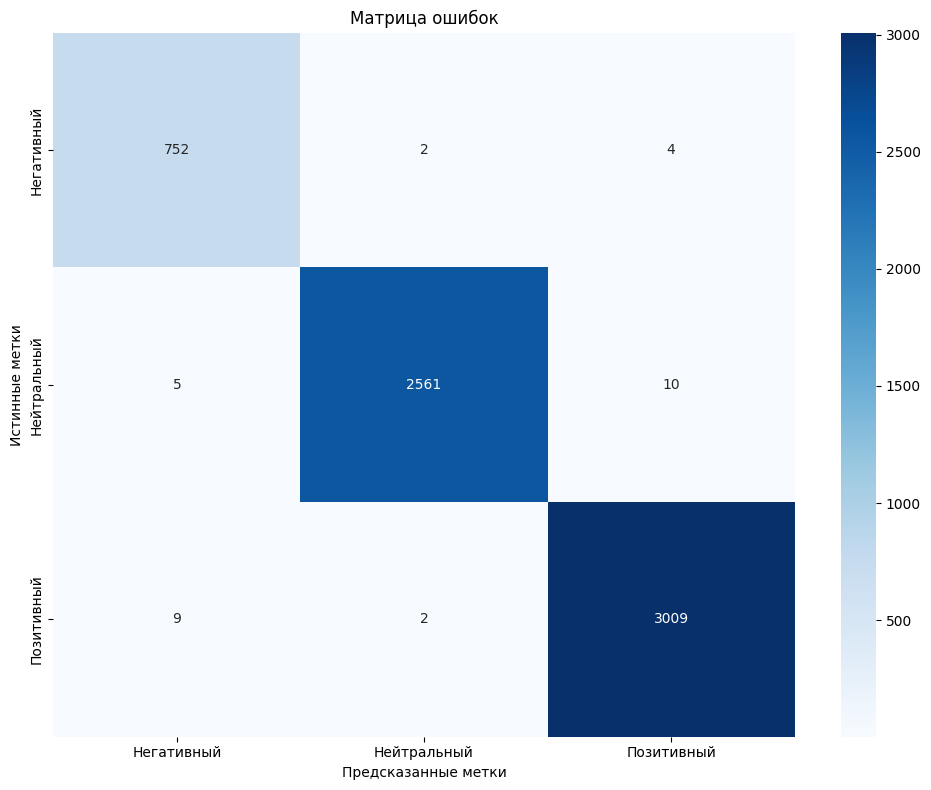


Misclassified examples:
                                                 text   true_label  \
0   Корпусом я полностью ДОВОЛЕН, СВОИХ денег он я...   Позитивный   
1   Купил в феврале 22 года, умер в феврале 24 год...   Позитивный   
2   Этот телик полный бюджет, не понятно за что он...   Позитивный   
3   Хорошая паровая швабра за свою цену. Немного н...   Негативный   
4   Брал именно эту модель без экрана с окончанием...   Позитивный   
5   Брал в 20м году под систему: Ryzen 5 3500x, 32...  Нейтральный   
6   давно хотел приобрести паровую швабру, так как...   Позитивный   
7   Не стоит жаловаться на региональность. Всё реш...  Нейтральный   
8   Моё первое знакомство с Термекс состоялось чут...   Позитивный   
9   Но когда видишь конечный результат работы шваб...   Негативный   
10  Отсутствие защелок не беда, провод плотно подк...  Нейтральный   
11                                         Рекоменлую  Нейтральный   
12                      В целом понравился, неплохой.   Негативны

SentimentClassifierWithLoRA(
  (base_model): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): LoRAWrapper(
                (base_layer): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoRALayer()
              )
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): LoRAWrapper(
                (base_layer): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoRALayer()
    

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

torch.manual_seed(42)

class LoRALayer(nn.Module):
    def __init__(self, in_features, out_features, rank=16, alpha=16):
        super().__init__()
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        self.lora_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))

    def forward(self, x, weight):
        base_output = torch.matmul(x, weight)
        lora_output = torch.matmul(torch.matmul(x, self.lora_A), self.lora_B) * self.scaling
        return base_output + lora_output

class LoRAWrapper(nn.Module):
    def __init__(self, base_layer, rank=16, alpha=16):
        super().__init__()
        self.base_layer = base_layer
        self.in_features = base_layer.in_features
        self.out_features = base_layer.out_features
        self.lora = LoRALayer(self.in_features, self.out_features, rank, alpha)

    def forward(self, x):
        return self.lora(x, self.base_layer.weight.T) + self.base_layer.bias

def apply_lora_to_model(model, target_modules=['query', 'value'], rank=16, alpha=16):
    for name, module in model.named_modules():
        if any(target in name for target in target_modules):
            if isinstance(module, nn.Linear):
                parent_name = '.'.join(name.split('.')[:-1])
                layer_name = name.split('.')[-1]
                parent_module = model
                for part in parent_name.split('.'):
                    if part:
                        parent_module = getattr(parent_module, part)

                lora_layer = LoRAWrapper(module, rank=rank, alpha=alpha)
                setattr(parent_module, layer_name, lora_layer)
    return model

class SentimentClassifierWithLoRA(nn.Module):
    def __init__(self, base_model, use_lora=True, lora_rank=16, lora_alpha=16):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, 3)

        if use_lora:
            self.base_model = apply_lora_to_model(
                self.base_model,
                target_modules=['query', 'value'],
                rank=lora_rank,
                alpha=lora_alpha
            )

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        return logits

    def get_lora_params(self):
        lora_params = []
        for name, module in self.named_modules():
            if isinstance(module, LoRAWrapper):
                lora_params.extend([module.lora.lora_A, module.lora.lora_B])
        return lora_params

tokenizer = AutoTokenizer.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
base_model = AutoModel.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")

for param in base_model.parameters():
    param.requires_grad = False

model = SentimentClassifierWithLoRA(base_model, use_lora=True, lora_rank=8, lora_alpha=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def count_trainable_params(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    lora_params = sum(p.numel() for p in model.get_lora_params())
    classifier_params = sum(p.numel() for p in model.classifier.parameters())

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"LoRA parameters: {lora_params:,}")
    print(f"Classifier parameters: {classifier_params:,}")
    print(f"Trainable percentage: {100 * trainable_params / total_params:.2f}%")

count_trainable_params(model)

def predict_sentiment(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        logits = model(inputs.input_ids, inputs.attention_mask)
        scores = torch.nn.functional.softmax(logits[0], dim=0).cpu().numpy()

    labels = ["Негативный", "Нейтральный", "Позитивный"]

    result = {
        "scores": {label: float(score) for label, score in zip(labels, scores)},
        "sentiment": labels[np.argmax(scores)],
        "confidence": float(np.max(scores)),
        "label_id": int(np.argmax(scores))
    }

    return result

def train_model_with_lora(model, train_texts, train_labels, val_texts=None, val_labels=None,
                          epochs=3, batch_size=16, learning_rate=3e-4):

    lora_params = model.get_lora_params()
    classifier_params = list(model.classifier.parameters())
    trainable_params = lora_params + classifier_params

    optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for i in tqdm(range(0, len(train_texts), batch_size), desc=f"Epoch {epoch+1}/{epochs}"):
            batch_texts = train_texts[i:i+batch_size]
            batch_labels = torch.tensor(train_labels[i:i+batch_size]).to(device)

            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                              max_length=512, padding=True).to(device)

            optimizer.zero_grad()
            logits = model(inputs.input_ids, inputs.attention_mask)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

        train_acc = correct / total
        avg_loss = total_loss / (len(train_texts) / batch_size)

        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Train Acc = {train_acc:.4f}")

        if val_texts is not None and val_labels is not None:
            val_acc = evaluate_accuracy(model, val_texts, val_labels)
            print(f"Validation Acc = {val_acc:.4f}")

def save_lora_weights(model, filepath):
    lora_state_dict = {}
    for name, module in model.named_modules():
        if isinstance(module, LoRAWrapper):
            lora_state_dict[f"{name}.lora_A"] = module.lora.lora_A
            lora_state_dict[f"{name}.lora_B"] = module.lora.lora_B
    lora_state_dict['classifier.weight'] = model.classifier.weight
    lora_state_dict['classifier.bias'] = model.classifier.bias
    torch.save(lora_state_dict, filepath)
    print(f"LoRA weights saved to {filepath}")

def load_lora_weights(model, filepath):
    lora_state_dict = torch.load(filepath, map_location=device)
    for name, module in model.named_modules():
        if isinstance(module, LoRAWrapper):
            if f"{name}.lora_A" in lora_state_dict:
                module.lora.lora_A.data = lora_state_dict[f"{name}.lora_A"]
                module.lora.lora_B.data = lora_state_dict[f"{name}.lora_B"]
    model.classifier.weight.data = lora_state_dict['classifier.weight']
    model.classifier.bias.data = lora_state_dict['classifier.bias']
    print(f"LoRA weights loaded from {filepath}")

def evaluate_accuracy(model, texts, labels):
    model.eval()
    predictions = []
    with torch.no_grad():
        for text in texts:
            result = predict_sentiment(text)
            predictions.append(result["label_id"])
    return accuracy_score(labels, predictions)

def print_sentiment_analysis(text, result):
    print(f"\nТекст: \"{text}\"")
    print(f"Сентимент: {result['sentiment']} (уверенность: {result['confidence']:.2%})")
    print("Подробные оценки:")
    for label, score in result['scores'].items():
        print(f"  {label}: {score:.2%}")
    print("-" * 50)

def evaluate_model(texts, true_labels):
    predictions = []
    pred_labels = []
    confidence_scores = []

    for text in tqdm(texts):
        result = predict_sentiment(text)
        predictions.append(result)
        pred_labels.append(result["label_id"])
        confidence_scores.append(result["confidence"])

    acc = accuracy_score(true_labels, pred_labels)
    report = classification_report(true_labels, pred_labels,
                                   target_names=["Негативный", "Нейтральный", "Позитивный"],
                                   output_dict=True)
    conf_matrix = confusion_matrix(true_labels, pred_labels)

    return {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": conf_matrix,
        "predictions": predictions,
        "pred_labels": pred_labels,
        "confidence_scores": confidence_scores
    }

def find_misclassified(texts, true_labels, evaluation_results):
    misclassified = []
    label_map = {0: "Негативный", 1: "Нейтральный", 2: "Позитивный"}

    for i, (text, true_label, pred_label) in enumerate(zip(texts, true_labels, evaluation_results["pred_labels"])):
        if true_label != pred_label:
            misclassified.append({
                "text": text,
                "true_label": label_map[true_label],
                "predicted_label": label_map[pred_label],
                "confidence": evaluation_results["confidence_scores"][i],
                "scores": evaluation_results["predictions"][i]["scores"]
            })

    return misclassified

def visualize_confusion_matrix(conf_matrix):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Негативный", "Нейтральный", "Позитивный"],
                yticklabels=["Негативный", "Нейтральный", "Позитивный"])
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title('Матрица ошибок')
    plt.tight_layout()
    plt.show()

def save_misclassified_to_dataframe(misclassified):
    df = pd.DataFrame(misclassified)
    for label in ["Негативный", "Нейтральный", "Позитивный"]:
        df[f'score_{label}'] = df['scores'].apply(lambda x: x[label])
    df.drop('scores', axis=1, inplace=True)
    return df

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

train_model_with_lora(
    model=model,
    train_texts=train_texts,
    train_labels=train_labels,
    val_texts=val_texts,
    val_labels=val_labels,
    epochs=25,
    batch_size=32,
    learning_rate=3e-4
)

evaluation_results = evaluate_model(val_texts, val_labels)
print(f"\nFinal validation accuracy: {evaluation_results['accuracy']:.4f}")
print("\nClassification Report:")
for label, metrics in evaluation_results['classification_report'].items():
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{label}: precision={metrics['precision']:.3f}, recall={metrics['recall']:.3f}, f1={metrics['f1-score']:.3f}")

visualize_confusion_matrix(evaluation_results['confusion_matrix'])

misclassified = find_misclassified(val_texts, val_labels, evaluation_results)
if misclassified:
    df_misclassified = save_misclassified_to_dataframe(misclassified)
    print("\nMisclassified examples:")
    print(df_misclassified)

save_lora_weights(model, 'lora_sentiment_model.pth')

load_lora_weights(model, 'lora_sentiment_model.pth')

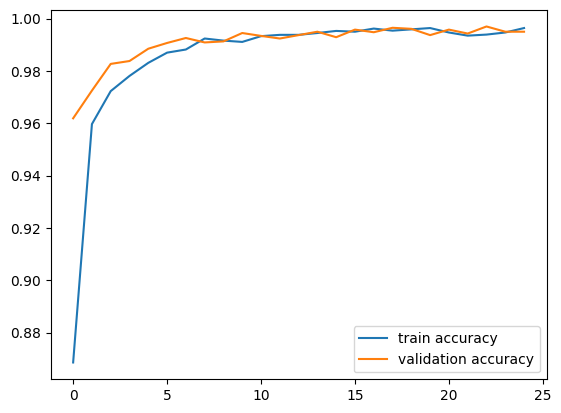

In [ ]:
plt.plot(evaluation_results['train_acc'], label='train accuracy')
plt.plot(evaluation_results['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

## Cross validate

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)

class LoRALayer(nn.Module):
    def __init__(self, in_features, out_features, rank=16, alpha=16):
        super().__init__()
        self.scaling = alpha / rank
        self.lora_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))
    def forward(self, x, weight):
        return torch.matmul(x, weight) + torch.matmul(torch.matmul(x, self.lora_A), self.lora_B) * self.scaling

class LoRAWrapper(nn.Module):
    def __init__(self, base_layer, rank=16, alpha=16):
        super().__init__()
        self.base_layer = base_layer
        self.lora = LoRALayer(base_layer.in_features, base_layer.out_features, rank, alpha)
    def forward(self, x):
        return self.lora(x, self.base_layer.weight.T) + self.base_layer.bias

def apply_lora_to_model(model, target_modules=['query', 'value'], rank=16, alpha=16):
    for name, module in model.named_modules():
        if any(target in name for target in target_modules) and isinstance(module, nn.Linear):
            parent_name, layer_name = '.'.join(name.split('.')[:-1]), name.split('.')[-1]
            parent_module = model
            for part in parent_name.split('.'):
                if part: parent_module = getattr(parent_module, part)
            setattr(parent_module, layer_name, LoRAWrapper(module, rank=rank, alpha=alpha))
    return model

class SentimentClassifierWithLoRA(nn.Module):
    def __init__(self, base_model, use_lora=True, lora_rank=16, lora_alpha=16):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, 3)
        if use_lora:
            self.base_model = apply_lora_to_model(self.base_model, ['query', 'value'], lora_rank, lora_alpha)
    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(outputs.last_hidden_state[:, 0])
    def get_lora_params(self):
        return [p for m in self.modules() if isinstance(m, LoRAWrapper) for p in [m.lora.lora_A, m.lora.lora_B]]

def save_lora_weights(model, fold, epoch):
    state = {}
    for name, module in model.named_modules():
        if isinstance(module, LoRAWrapper):
            state[f"{name}.lora_A"] = module.lora.lora_A.detach().cpu()
            state[f"{name}.lora_B"] = module.lora.lora_B.detach().cpu()
    state['classifier.weight'] = model.classifier.weight.detach().cpu()
    state['classifier.bias'] = model.classifier.bias.detach().cpu()
    torch.save(state, f'lora_fold{fold}_epoch{epoch}.pth')

def evaluate(model, texts, labels, batch_size=32):
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
            logits = model(inputs.input_ids, inputs.attention_mask)
            predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
    return accuracy_score(labels, predictions)

tokenizer = AutoTokenizer.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
base_model = AutoModel.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
for param in base_model.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_fold(model, train_texts, train_labels, val_texts, val_labels, fold, epochs=3, batch_size=16, lr=3e-4):
    optimizer = torch.optim.AdamW(model.get_lora_params() + list(model.classifier.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs = [], []

    for epoch in tqdm(range(epochs), desc=f"Fold {fold}"):
        model.train()
        for i in range(0, len(train_texts), batch_size):
            batch_texts = train_texts[i:i+batch_size]
            batch_labels = torch.tensor(train_labels[i:i+batch_size]).to(device)
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs.input_ids, inputs.attention_mask), batch_labels)
            loss.backward()
            optimizer.step()

        train_acc = evaluate(model, train_texts, train_labels, batch_size)
        val_acc = evaluate(model, val_texts, val_labels, batch_size)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        save_lora_weights(model, fold, epoch+1)

    return train_accs, val_accs

texts = np.array(texts)
labels = np.array(labels)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_train_accs = []
all_val_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(texts[:10]), 1):
    print(f"Fold {fold}/5")
    model = SentimentClassifierWithLoRA(base_model, use_lora=True, lora_rank=8, lora_alpha=16).to(device)
    train_accs, val_accs = train_fold(model, texts[train_idx].tolist(), labels[train_idx].tolist(),
                                      texts[val_idx].tolist(), labels[val_idx].tolist(), fold, epochs=10, batch_size=32)
    all_train_accs.append(train_accs)
    all_val_accs.append(val_accs)
    print(f"Fold {fold} final val accuracy: {val_accs[-1]:.4f}")


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)

class LoRALayer(nn.Module):
    def __init__(self, in_features, out_features, rank=16, alpha=16):
        super().__init__()
        self.scaling = alpha / rank
        self.lora_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))
    def forward(self, x, weight):
        return torch.matmul(x, weight) + torch.matmul(torch.matmul(x, self.lora_A), self.lora_B) * self.scaling

class LoRAWrapper(nn.Module):
    def __init__(self, base_layer, rank=16, alpha=16):
        super().__init__()
        self.base_layer = base_layer
        self.weight = base_layer.weight
        self.bias = base_layer.bias
        self.lora = LoRALayer(base_layer.in_features, base_layer.out_features, rank, alpha)
    def forward(self, x):
        return self.lora(x, self.weight.T) + self.bias

def apply_lora_to_model(model, target_modules=['query', 'value'], rank=16, alpha=16):
    for name, module in model.named_modules():
        if any(target in name for target in target_modules) and isinstance(module, nn.Linear):
            parent_name, layer_name = '.'.join(name.split('.')[:-1]), name.split('.')[-1]
            parent_module = model
            for part in parent_name.split('.'):
                if part: parent_module = getattr(parent_module, part)
            setattr(parent_module, layer_name, LoRAWrapper(module, rank=rank, alpha=alpha))
    return model

class SentimentClassifierWithLoRA(nn.Module):
    def __init__(self, base_model, use_lora=True, lora_rank=16, lora_alpha=16):
        super().__init__()
        self.base_model = copy.deepcopy(base_model)
        self.classifier = nn.Linear(self.base_model.config.hidden_size, 3)
        if use_lora:
            self.base_model = apply_lora_to_model(self.base_model, ['query', 'value'], lora_rank, lora_alpha)
    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(outputs.last_hidden_state[:, 0])
    def get_lora_params(self):
        return [p for m in self.modules() if isinstance(m, LoRAWrapper) for p in [m.lora.lora_A, m.lora.lora_B]]

def save_lora_weights(model, fold, epoch):
    state = {}
    for name, module in model.named_modules():
        if isinstance(module, LoRAWrapper):
            state[f"{name}.lora_A"] = module.lora.lora_A.detach().cpu()
            state[f"{name}.lora_B"] = module.lora.lora_B.detach().cpu()
    state['classifier.weight'] = model.classifier.weight.detach().cpu()
    state['classifier.bias'] = model.classifier.bias.detach().cpu()
    torch.save(state, f'lora_fold{fold}_epoch{epoch}.pth')

def evaluate(model, texts, labels, batch_size=32):
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
            logits = model(inputs.input_ids, inputs.attention_mask)
            predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
    return accuracy_score(labels, predictions)

tokenizer = AutoTokenizer.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
base_model = AutoModel.from_pretrained("sismetanin/xlm_roberta_base-ru-sentiment-rusentiment")
for param in base_model.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_fold(model, train_texts, train_labels, val_texts, val_labels, fold, epochs=3, batch_size=16, lr=3e-4):
    optimizer = torch.optim.AdamW(model.get_lora_params() + list(model.classifier.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs = [], []

    for epoch in tqdm(range(epochs), desc=f"Fold {fold}"):
        model.train()
        for i in range(0, len(train_texts), batch_size):
            batch_texts = train_texts[i:i+batch_size]
            batch_labels = torch.tensor(train_labels[i:i+batch_size]).to(device)
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs.input_ids, inputs.attention_mask), batch_labels)
            loss.backward()
            optimizer.step()

        train_acc = evaluate(model, train_texts, train_labels, batch_size)
        val_acc = evaluate(model, val_texts, val_labels, batch_size)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        save_lora_weights(model, fold, epoch+1)

    return train_accs, val_accs

texts = np.array(texts)
labels = np.array(labels)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_train_accs = []
all_val_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(texts), 1):
    print(f"Fold {fold}/5")
    model = SentimentClassifierWithLoRA(base_model, use_lora=True, lora_rank=8, lora_alpha=16).to(device)
    train_accs, val_accs = train_fold(model, texts[train_idx].tolist(), labels[train_idx].tolist(),
                                      texts[val_idx].tolist(), labels[val_idx].tolist(), fold, epochs=10, batch_size=32)
    all_train_accs.append(train_accs)
    all_val_accs.append(val_accs)
    print(f"Fold {fold} final val accuracy: {val_accs[-1]:.4f}")

Some weights of XLMRobertaModel were not initialized from the model checkpoint at sismetanin/xlm_roberta_base-ru-sentiment-rusentiment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fold 1/5


Fold 1: 100%|██████████| 10/10 [1:40:47<00:00, 604.77s/it]


Fold 1 final val accuracy: 0.9958
Fold 2/5


Fold 2: 100%|██████████| 10/10 [1:39:30<00:00, 597.08s/it]


...

Fold 3: 100%|██████████| 10/10 [1:41:49<00:00, 610.94s/it]


Fold 3 final val accuracy: 0.9955
Fold 4/5


Fold 4: 100%|██████████| 10/10 [1:39:47<00:00, 598.79s/it]


Fold 4 final val accuracy: 0.9950
Fold 5/5


Fold 5:  50%|█████     | 5/10 [50:34<50:34, 606.90s/it]  

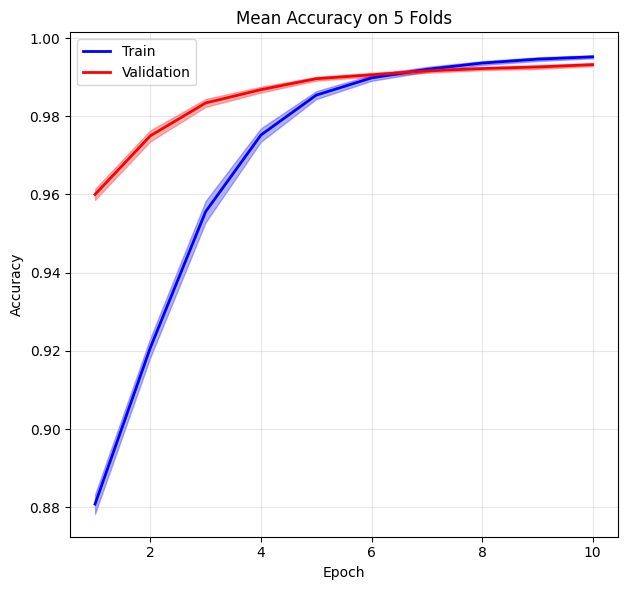

In [ ]:
all_train_accs = np.array(all_train_accs)
all_val_accs = np.array(all_val_accs)

mean_train = np.mean(all_train_accs, axis=0)
std_train = np.std(all_train_accs, axis=0)
mean_val = np.mean(all_val_accs, axis=0)
std_val = np.std(all_val_accs, axis=0)

epochs = np.arange(1, len(mean_train) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, mean_train, 'b-', label='Train', linewidth=2)
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.3, color='blue')
plt.plot(epochs, mean_val, 'r-', label='Validation', linewidth=2)
plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.3, color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Mean Accuracy on 5 Folds')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# XML_RoBERTa_Large

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_NAME = "sismetanin/xlm_roberta_large-ru-sentiment-rureviews"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        scores = outputs.logits[0].cpu().numpy()
        scores = torch.nn.functional.softmax(torch.tensor(scores), dim=0).numpy()
    labels = ["Негативный", "Нейтральный", "Позитивный"]

    result = {
        "scores": {label: float(score) for label, score in zip(labels, scores)},
        "sentiment": labels[np.argmax(scores)],
        "confidence": float(np.max(scores)),
        "label_id": int(np.argmax(scores))
    }

    return result

def print_sentiment_analysis(text, result):
    print(f"\nТекст: \"{text}\"")
    print(f"Сентимент: {result['sentiment']} (уверенность: {result['confidence']:.2%})")
    print("Подробные оценки:")
    for label, score in result['scores'].items():
        print(f"  {label}: {score:.2%}")
    print("-" * 50)

def evaluate_model(texts, true_labels):
    predictions = []
    pred_labels = []
    confidence_scores = []

    for text in texts:
        result = predict_sentiment(text)
        predictions.append(result)
        pred_labels.append(result["label_id"])
        confidence_scores.append(result["confidence"])

    acc = accuracy_score(true_labels, pred_labels)
    report = classification_report(true_labels, pred_labels,
                                   target_names=["Негативный", "Нейтральный", "Позитивный"],
                                   output_dict=True)

    return {
        "accuracy": acc,
        "classification_report": report,
        "predictions": predictions,
        "pred_labels": pred_labels,
        "confidence_scores": confidence_scores
    }

def find_misclassified(texts, true_labels, evaluation_results):
    misclassified = []
    label_map = {0: "Негативный", 1: "Нейтральный", 2: "Позитивный"}

    for i, (text, true_label, pred_label) in enumerate(zip(texts, true_labels, evaluation_results["pred_labels"])):
        if true_label != pred_label:
            misclassified.append({
                "text": text,
                "true_label": label_map[true_label],
                "predicted_label": label_map[pred_label],
                "confidence": evaluation_results["confidence_scores"][i],
                "scores": evaluation_results["predictions"][i]["scores"]
            })

    return misclassified

def visualize_confusion_matrix(conf_matrix):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Негативный", "Нейтральный", "Позитивный"],
                yticklabels=["Негативный", "Нейтральный", "Позитивный"])
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title('Матрица ошибок')
    plt.tight_layout()

    plt.show()

def save_misclassified_to_dataframe(misclassified):
    df = pd.DataFrame(misclassified)
    for label in ["Негативный", "Нейтральный", "Позитивный"]:
        df[f'score_{label}'] = df['scores'].apply(lambda x: x[label])
    df.drop('scores', axis=1, inplace=True)

    return df


evaluation_results = evaluate_model(texts, labels)

In [ ]:
result = evaluation_results['classification_report']

report_df = pd.DataFrame({
    'accuracy': result['accuracy'],
    'recall macro': result['recall'],
    'precision macro': result['precision'],
    'f1-score macro': result['f1-score'],
}).transpose()
display(report_df)

,accuracy,precision macro,recall macro,f1-score macro
mean,0.66,0.55,0.47,0.51


# Mistral

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
import time

def label_to_name(label):
    if label == 0:
        return 'negative'
    elif label == 1:
        return 'neutral'
    elif label == 2:
        return 'positive'
    else:
        raise ValueError(f'Wrong label {label}')


def load_ministral_model():
    model_name = "mistralai/Ministral-8B-Instruct-2410"

    print(f"Загрузка модели {model_name}...")
    start_time = time.time()

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        dtype=torch.bfloat16
    )

    device = next(model.parameters()).device
    print(f"Модель загружена за {time.time() - start_time:.2f} секунд")

    return model, tokenizer



def analyze_sentiment_with_ministral(text, model, tokenizer):
    prompt = f'''You are a classifier of text sentiment on russian language.
                You must return only one value - sentiment of text.
                Choose only between 3 words: negative, neutral, positive.
                Text: "{text}"
                Sentiment:'''

    inputs = tokenizer(prompt, return_tensors="pt")

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    full_response = tokenizer.decode(outputs[0], skip_special_tokens=False)
    sentiment = full_response[-20:]

    valid_labels = ["positive", "negative", "neutral"]
    for label in valid_labels:
        if label in sentiment.lower():
            sentiment = label
            break
    if sentiment not in valid_labels:
        sentiment = "neutral"

    return {
        "text": text,
        "sentiment": sentiment
    }


def batch_analyze_with_ministral(texts, model, tokenizer, batch_size=10):
    results = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Анализ текстов"):
        batch = texts[i:i+batch_size]

        for text in batch:
            result = analyze_sentiment_with_ministral(text, model, tokenizer)
            results.append(result)

    return results


def calculate_classification_metrics(true_labels, predicted_labels):
    unique_labels = sorted(set(true_labels + predicted_labels))

    precision, recall, f1, support = precision_recall_fscore_support(
        true_labels, predicted_labels, labels=unique_labels, average=None
    )

    accuracy = accuracy_score(true_labels, predicted_labels)

    metrics = {
        "accuracy": accuracy,
        "class_metrics": {
            label: {
                "precision": p,
                "recall": r,
                "f1": f,
                "support": s
            } for label, p, r, f, s in zip(unique_labels, precision, recall, f1, support)
        }
    }

    return metrics


def evaluate_model_with_dataset(dataset, label, model, tokenizer):
    texts = [item for item in dataset]
    true_labels = [label_to_name(item) for item in label]

    predictions = batch_analyze_with_ministral(texts, model, tokenizer)
    predicted_labels = [item['sentiment'] for item in predictions]

    metrics = calculate_classification_metrics(true_labels, predicted_labels)

    results_df = pd.DataFrame({
        'text': texts,
        'true_label': true_labels,
        'predicted_label': predicted_labels,
        'correct': [t == p for t, p in zip(true_labels, predicted_labels)]
    })

    return {
        'metrics': metrics,
        'results_df': results_df,
        'predictions': predictions
    }

model, tokenizer = load_ministral_model()
eval_results = evaluate_model_with_dataset(texts, labels, model, tokenizer)


In [ ]:
import pandas as pd

def metrics_to_df(metrics_dict):
    df = pd.DataFrame(metrics_dict['class_metrics']).T
    macro_metrics = pd.Series({
        'accuracy': metrics_dict['accuracy'],
        'macro_precision': df['precision'].mean(),
        'macro_recall': df['recall'].mean(),
        'macro_f1': df['f1'].mean()
    })
    return df, macro_metrics

df, metrics = metrics_to_df(eval_results['metrics'])
metrics


accuracy           0.646700
macro_precision    0.623333
macro_recall       0.474633
macro_f1           0.565833
dtype: float64

# Gemma-3

In [ ]:
!pip install transformers accelerate bitsandbytes

In [ ]:
!pip install -U bitsandbytes

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

MODEL_NAME = "VIDraft/Gemma-3-R1984-1B"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto"
)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
generation_config = GenerationConfig.from_pretrained(MODEL_NAME)
print(generation_config)

prompts = [f'''You are a classifier of text sentiment
        on russian language. You must return only one value - sentiment of text - you can use only choose between 3 words: negative, neutral, positive
        Text: "{text}"

        Sentiment:''' for text in texts]



config.json:   0%|          | 0.00/893 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

GenerationConfig {
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "do_sample": true,
  "eos_token_id": [
    1,
    106
  ],
  "pad_token_id": 0,
  "top_k": 64,
  "top_p": 0.95
}



In [ ]:
outputs = []
for query in tqdm(prompts):
    prompt = tokenizer.apply_chat_template([{
        "role": "user",
        "content": query
    }], tokenize=False, add_generation_prompt=True)
    data = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
    data = {k: v.to(model.device) for k, v in data.items()}
    data.pop("token_type_ids", None)
    output_ids = model.generate(**data, generation_config=generation_config)[0]
    output_ids = output_ids[len(data["input_ids"][0]):]
    output = tokenizer.decode(output_ids, skip_special_tokens=True).strip()
    outputs.append(output)

In [ ]:
preds = []
for output in outputs:
    pred = output.lower()
    if 'positive' in pred:
        pred = 2
    elif 'negative' in pred:
        pred = 0
    else:
        pred = 1
    preds.append(pred)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {}
metrics['accuracy'] = accuracy_score(labels, preds)
metrics['precision'] = precision_score(labels, preds, average='macro', zero_division=0)
metrics['recall'] = recall_score(labels, preds, average='macro', zero_division=0)
metrics['f1'] = f1_score(labels, preds, average='macro', zero_division=0)

pd.Series(metrics)

accuracy     0.73344
precision    0.62722
recall       0.47401
f1           0.57212
dtype: float64